# Detecting Fake Job Postings with Text Mining

**Goal:** Fraudulent job postings lead to financial scams and identity theft.
This project builds a text classification pipeline to flag fraudulent postings
from real ones, under heavy class imbalance (fraud is <5% of postings).

**Dataset:** ["Real / Fake Job Posting Prediction"](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction)
(Kaggle, shivamb) — 17,880 real job postings, 18 columns, 4.84% labeled fraudulent.

**Scope note:** this notebook reproduces the traditional ML baseline, SMOTE
resampling, and feature-importance analysis end to end. The deep learning
(CNN/LSTM/BiLSTM) and BERT fine-tuning results are cited from the original
project run — that training was done on GPU (Colab) originally, and
re-fine-tuning BERT for 5 epochs on CPU here isn't practical. See the
project README for the full original write-up and those results.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import WordPunctTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
import os

BLUE, AQUA, ORANGE, RED, VIOLET = "#2a78d6", "#1baf7a", "#eb6834", "#e34948", "#4a3aa7"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
CHART_DIR = "../assets"
os.makedirs(CHART_DIR, exist_ok=True)
SEED = 42

## 1. Load & explore

In [2]:
df = pd.read_csv("../data/fake_job_postings.csv")
print(df.shape)
df[["title", "location", "description", "fraudulent"]].head(3)

(17880, 18)


,title,location,description,fraudulent
0,Marketing Intern,"US, NY, New York","Food52, a fast-growing, James Beard Award-winn...",0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Organised - Focused - Vibrant - Awesome!Do you...,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever","Our client, located in Houston, is actively se...",0


fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.16
1     4.84
Name: count, dtype: float64


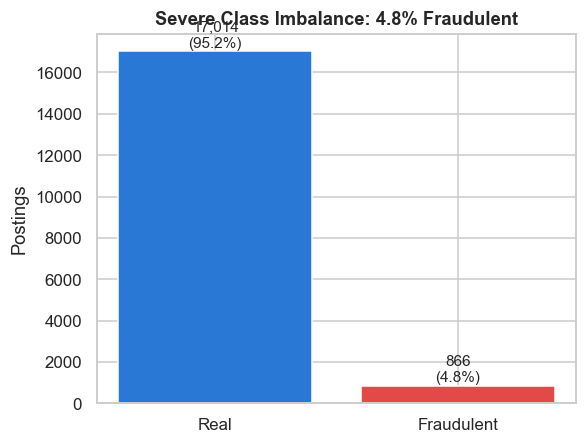

In [3]:
class_counts = df["fraudulent"].value_counts()
print(class_counts)
print((class_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(5.5, 4.2))
labels = ["Real", "Fraudulent"]
colors = [BLUE, RED]
ax.bar(labels, class_counts.reindex([0, 1]).values, color=colors)
for i, v in enumerate(class_counts.reindex([0, 1]).values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=10)
ax.set_ylabel("Postings")
ax.set_title("Severe Class Imbalance: 4.8% Fraudulent", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/class_imbalance.png", dpi=150)
plt.show()

## 2. Preprocessing

Fill missing text fields, combine into one document per posting, then clean
(lowercase, strip punctuation/numbers, remove stopwords, lemmatize).

In [4]:
text_cols = ["title", "location", "company_profile", "description", "requirements", "benefits"]
for col in text_cols:
    df[col] = df[col].fillna("NA")

df["combined_text"] = df[text_cols].agg(" ".join, axis=1)

lemmatizer = WordNetLemmatizer()
tokenizer = WordPunctTokenizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = tokenizer.tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["combined_text"].apply(clean_text)
df[["combined_text", "clean_text"]].head(2)

,combined_text,clean_text
0,"Marketing Intern US, NY, New York We're Food52...",marketing intern new york food created groundb...
1,"Customer Service - Cloud Video Production NZ, ...",customer service cloud video production auckla...


## 3. Train/test split & feature extraction

80/20 stratified split; vectorizers fit on training data only to avoid leakage.

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["fraudulent"], test_size=0.2, stratify=df["fraudulent"], random_state=SEED
)
print(f"Train: {len(X_train_text)} | Test: {len(X_test_text)} | Train fraud rate: {y_train.mean():.2%}")

tfidf = TfidfVectorizer(max_features=2000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

countvec = CountVectorizer(max_features=2000)
X_train_cv = countvec.fit_transform(X_train_text)
X_test_cv = countvec.transform(X_test_text)

Train: 14304 | Test: 3576 | Train fraud rate: 4.84%


## 4. Baseline models (no resampling)

Macro-averaged precision/recall/F1 + balanced accuracy — accuracy alone is
meaningless at 95/5 class split (predicting "real" for everything scores 95%).

In [6]:
def evaluate(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    return dict(balanced_acc=bal_acc, precision=p, recall=r, f1=f1)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "SVM": SVC(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
}

baseline_results = []
fitted_baseline = {}
for vec_name, (X_train, X_test) in [("TF-IDF", (X_train_tfidf, X_test_tfidf)), ("CountVec", (X_train_cv, X_test_cv))]:
    for model_name, model in models.items():
        m = model.__class__(**model.get_params())
        m.fit(X_train, y_train)
        preds = m.predict(X_test)
        res = evaluate(y_test, preds)
        res.update(vectorizer=vec_name, model=model_name)
        baseline_results.append(res)
        fitted_baseline[(vec_name, model_name)] = m

baseline_df = pd.DataFrame(baseline_results)[["vectorizer", "model", "balanced_acc", "precision", "recall", "f1"]]
baseline_df.round(3).sort_values("f1", ascending=False)

,vectorizer,model,balanced_acc,precision,recall,f1
5,CountVec,Logistic Regression,0.885,0.887,0.885,0.886
2,TF-IDF,SVM,0.795,0.990,0.795,0.866
7,CountVec,Random Forest,0.789,0.989,0.789,0.861
3,TF-IDF,Random Forest,0.783,0.989,0.783,0.856
6,CountVec,SVM,0.757,0.988,0.757,0.834
1,TF-IDF,Logistic Regression,0.717,0.986,0.717,0.795
0,TF-IDF,Naive Bayes,0.639,0.982,0.639,0.708
4,CountVec,Naive Bayes,0.864,0.649,0.864,0.698


## 5. SMOTE resampling

Fraudulent postings are <5% of the data — SMOTE generates synthetic minority
examples on the *training* set only (never touching test data) to see if
resampling improves recall on the class that actually matters.

In [7]:
smote_results = []
for vec_name, (X_train, X_test) in [("TF-IDF", (X_train_tfidf, X_test_tfidf)), ("CountVec", (X_train_cv, X_test_cv))]:
    X_train_res, y_train_res = SMOTE(random_state=SEED).fit_resample(X_train, y_train)
    for model_name, model in models.items():
        m = model.__class__(**model.get_params())
        m.fit(X_train_res, y_train_res)
        preds = m.predict(X_test)
        res = evaluate(y_test, preds)
        res.update(vectorizer=vec_name, model=f"{model_name} + SMOTE")
        smote_results.append(res)

smote_df = pd.DataFrame(smote_results)[["vectorizer", "model", "balanced_acc", "precision", "recall", "f1"]]
smote_df.round(3).sort_values("f1", ascending=False)

,vectorizer,model,balanced_acc,precision,recall,f1
2,TF-IDF,SVM + SMOTE,0.849,0.980,0.849,0.903
3,TF-IDF,Random Forest + SMOTE,0.829,0.983,0.829,0.890
7,CountVec,Random Forest + SMOTE,0.823,0.898,0.823,0.856
1,TF-IDF,Logistic Regression + SMOTE,0.912,0.808,0.912,0.851
5,CountVec,Logistic Regression + SMOTE,0.893,0.816,0.893,0.850
6,CountVec,SVM + SMOTE,0.843,0.820,0.843,0.831
4,CountVec,Naive Bayes + SMOTE,0.813,0.767,0.813,0.788
0,TF-IDF,Naive Bayes + SMOTE,0.890,0.666,0.890,0.719


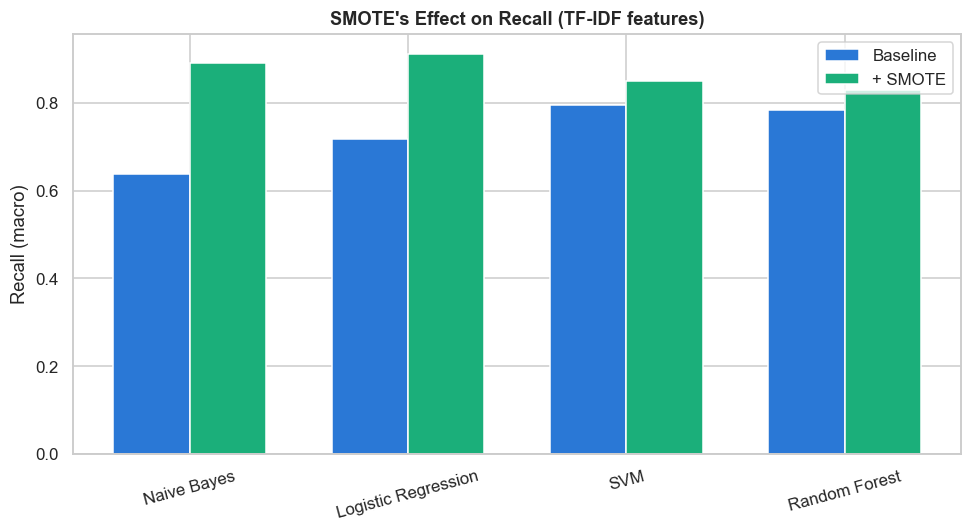

In [8]:
compare = pd.concat([baseline_df.assign(group="Baseline"), smote_df.assign(group="+ SMOTE")])
best_per_model_tfidf = compare[compare["vectorizer"] == "TF-IDF"].copy()
best_per_model_tfidf["base_model"] = best_per_model_tfidf["model"].str.replace(" + SMOTE", "", regex=False)

fig, ax = plt.subplots(figsize=(9, 5))
pivot = best_per_model_tfidf.pivot(index="base_model", columns="group", values="recall")
pivot = pivot.reindex(["Naive Bayes", "Logistic Regression", "SVM", "Random Forest"])
x = np.arange(len(pivot))
width = 0.35
ax.bar(x - width/2, pivot["Baseline"], width, label="Baseline", color=BLUE)
ax.bar(x + width/2, pivot["+ SMOTE"], width, label="+ SMOTE", color=AQUA)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15)
ax.set_ylabel("Recall (macro)")
ax.set_title("SMOTE's Effect on Recall (TF-IDF features)", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/smote_effect.png", dpi=150)
plt.show()

## 6. Feature importance

Logistic Regression + TF-IDF coefficients show which words push a posting
toward "fraudulent" vs "real."

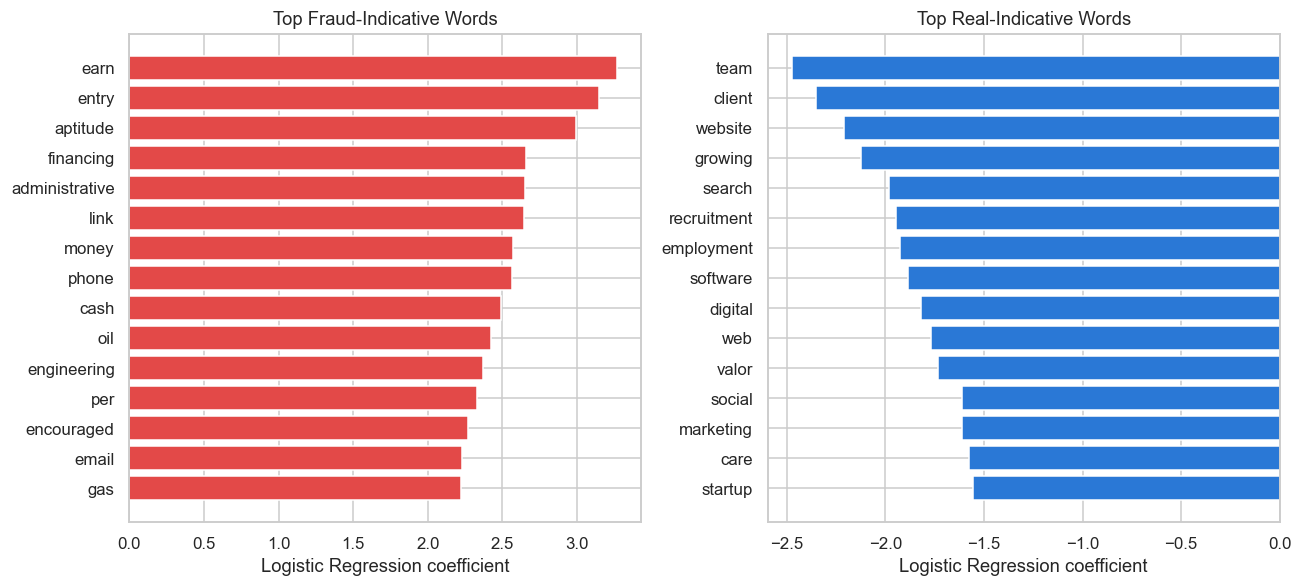

In [9]:
logreg_tfidf = fitted_baseline[("TF-IDF", "Logistic Regression")]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = logreg_tfidf.coef_[0]

top_fraud_idx = np.argsort(coefs)[-15:][::-1]
top_real_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].barh(feature_names[top_fraud_idx][::-1], coefs[top_fraud_idx][::-1], color=RED)
axes[0].set_title("Top Fraud-Indicative Words")
axes[1].barh(feature_names[top_real_idx][::-1], coefs[top_real_idx][::-1], color=BLUE)
axes[1].set_title("Top Real-Indicative Words")
for ax in axes:
    ax.set_xlabel("Logistic Regression coefficient")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/feature_importance.png", dpi=150)
plt.show()

## 7. Summary table (this notebook's reproduced results)

In [10]:
summary = compare[compare["vectorizer"].isin(["TF-IDF", "CountVec"])].sort_values("f1", ascending=False).head(10)
summary[["vectorizer", "model", "balanced_acc", "precision", "recall", "f1"]].round(3)

,vectorizer,model,balanced_acc,precision,recall,f1
2,TF-IDF,SVM + SMOTE,0.849,0.980,0.849,0.903
3,TF-IDF,Random Forest + SMOTE,0.829,0.983,0.829,0.890
5,CountVec,Logistic Regression,0.885,0.887,0.885,0.886
2,TF-IDF,SVM,0.795,0.990,0.795,0.866
7,CountVec,Random Forest,0.789,0.989,0.789,0.861
3,TF-IDF,Random Forest,0.783,0.989,0.783,0.856
7,CountVec,Random Forest + SMOTE,0.823,0.898,0.823,0.856
1,TF-IDF,Logistic Regression + SMOTE,0.912,0.808,0.912,0.851
5,CountVec,Logistic Regression + SMOTE,0.893,0.816,0.893,0.850
6,CountVec,SVM,0.757,0.988,0.757,0.834


## 8. Deep learning & BERT (from the original project run)

Not re-executed here (CNN/LSTM/BiLSTM need TensorFlow; BERT fine-tuning for
5 epochs on 17,880 documents needs a GPU — infeasible on CPU in this
environment). These are the original results, trained on Colab:

| Model | Type | Balanced Acc. | Precision | Recall | F1 |
|---|---|---|---|---|---|
| CNN | Deep Learning | 0.930 | 0.99 | 0.93 | 0.96 |
| BiLSTM | Deep Learning | 0.930 | 0.99 | 0.93 | 0.96 |
| LSTM | Deep Learning | 0.500 | 0.49 | 0.50 | 0.49 |
| BERT (fine-tuned) | Transformer | 0.930 | 0.96 | 0.93 | 0.94 |

CNN and BiLSTM won outright; unidirectional LSTM collapsed to predicting the
majority class. See the project README for the full discussion (including
why LSTM likely failed, and qualitative error analysis across all models).